# Продуктовая и маркетинговая аналитика

Витрины `mart_channel_economics`, `mart_customer_ltv`, `mart_cohort_retention` (см. `sql/marts.sql`) построены поверх staging-таблиц, которые наполняет ETL-пайплайн из соседнего репозитория [`etl-portfolio`](../etl-portfolio). Здесь — Python-слой: визуализация и интерпретация того, что посчитал SQL.

In [1]:
import os
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

from src.analytics.visualization import plot_romi_by_channel

load_dotenv('../.env')
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER','postgres')}:{os.getenv('DB_PASSWORD','')}"
    f"@{os.getenv('DB_HOST','localhost')}:{os.getenv('DB_PORT','5432')}/{os.getenv('DB_NAME','etl_portfolio')}"
)
plt.rcParams['figure.dpi'] = 110

## 1. ROMI по каналам

Вопрос, который решает эта витрина: **какие каналы приносят прибыль на маркетинговые вложения, а какие пора отключать или пересматривать**.

In [2]:
channel_summary = pd.read_sql("""
    SELECT channel,
           SUM(spend) AS total_spend,
           SUM(leads) AS total_leads,
           SUM(customers_acquired) AS total_customers,
           ROUND(SUM(spend) / NULLIF(SUM(leads), 0), 2) AS avg_cpl,
           ROUND(SUM(spend) / NULLIF(SUM(customers_acquired), 0), 2) AS avg_cac,
           ROUND((SUM(revenue_same_month) - SUM(spend)) / NULLIF(SUM(spend), 0), 3) AS romi
    FROM mart_channel_economics
    GROUP BY channel
    ORDER BY romi DESC
""", engine)
channel_summary

,channel,total_spend,total_leads,total_customers,avg_cpl,avg_cac,romi
0,referral,639.36,55,27.0,11.62,23.68,78.949
1,seo,3006.72,199,44.0,15.11,68.33,21.961
2,email,647.09,112,17.0,5.78,38.06,19.391
3,context_ads,9309.36,207,71.0,44.97,131.12,16.701
4,social_ads,7540.08,225,41.0,33.51,183.90,10.070


График строит `plot_romi_by_channel` из `src/analytics/visualization.py` — покрытая тестом функция (`tests/test_visualization.py`), а не одноразовый код внутри ячейки.

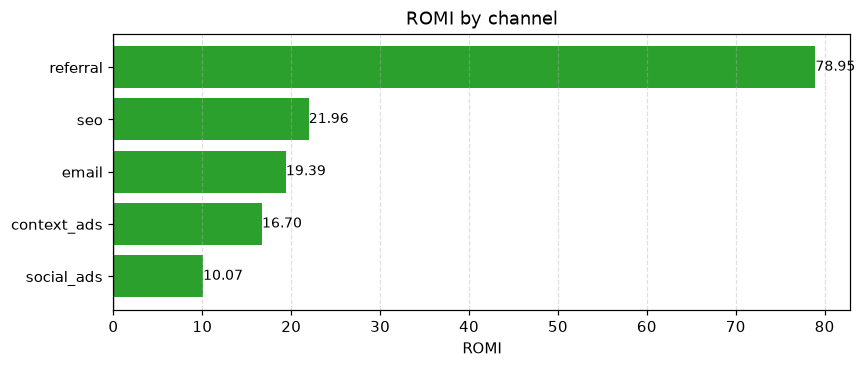

In [3]:
fig = plot_romi_by_channel(channel_summary)
plt.show()

## 2. LTV: накопительная выручка по номеру заказа

`mart_customer_ltv` считает это оконной функцией `SUM() OVER (PARTITION BY customer_id ORDER BY order_date)` — без единого `GROUP BY`. Здесь агрегируем средний LTV по глубине заказа, чтобы увидеть, сколько в среднем приносит клиент к N-му заказу.

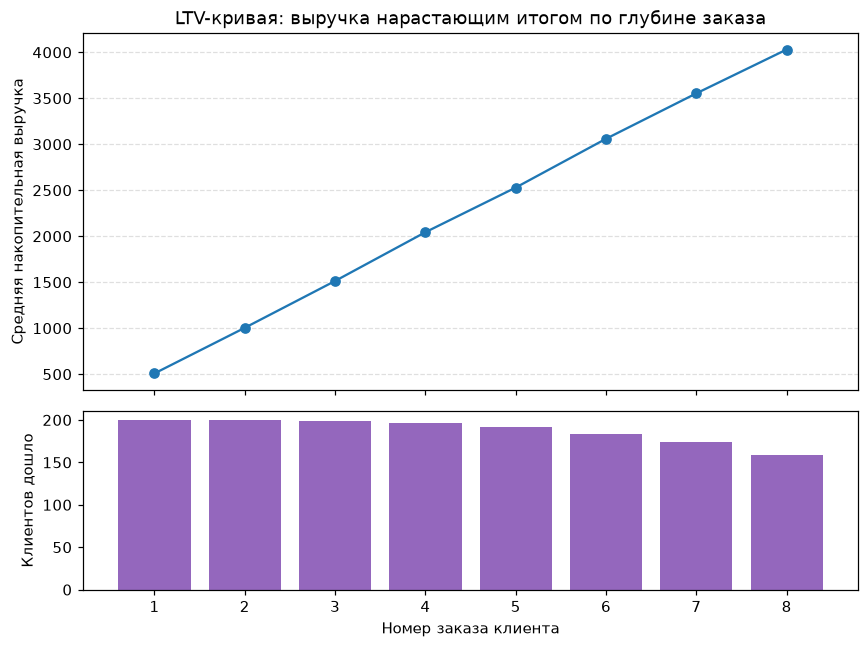

In [4]:
ltv_by_seq = pd.read_sql("""
    SELECT order_seq, AVG(cumulative_revenue) AS avg_cumulative_revenue, COUNT(*) AS customers_reaching
    FROM mart_customer_ltv
    WHERE order_seq <= 8
    GROUP BY order_seq
    ORDER BY order_seq
""", engine)

# Два раздельных графика с общей осью X вместо twin-axis: разные величины
# (деньги и число клиентов) не должны делить одну плоскость с двумя шкалами
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=[2, 1])

ax1.plot(ltv_by_seq['order_seq'], ltv_by_seq['avg_cumulative_revenue'], marker='o', color='#1f77b4')
ax1.set_ylabel('Средняя накопительная выручка')
ax1.set_title('LTV-кривая: выручка нарастающим итогом по глубине заказа')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2.bar(ltv_by_seq['order_seq'], ltv_by_seq['customers_reaching'], color='#9467bd')
ax2.set_xlabel('Номер заказа клиента')
ax2.set_ylabel('Клиентов дошло')

plt.tight_layout()
plt.show()

## 3. Ретеншн по когортам

`mart_cohort_retention` — классический cohort-анализ: доля клиентов когорты, оформивших заказ через N месяцев после регистрации.

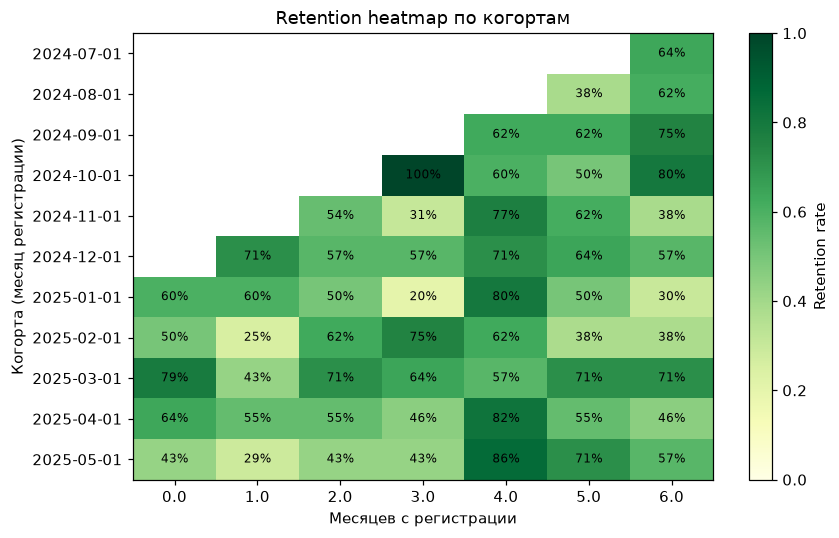

In [5]:
cohort = pd.read_sql("""
    SELECT cohort_month, month_number, retention_rate
    FROM mart_cohort_retention
    WHERE month_number BETWEEN 0 AND 6
""", engine)

pivot = cohort.pivot(index='cohort_month', columns='month_number', values='retention_rate')

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='YlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([str(d) for d in pivot.index])
ax.set_xlabel('Месяцев с регистрации')
ax.set_ylabel('Когорта (месяц регистрации)')
ax.set_title('Retention heatmap по когортам')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Retention rate')
plt.tight_layout()
plt.show()

## Вывод

- **social_ads** и **context_ads** — самые дорогие каналы по CAC при этом с наименьшим ROMI среди прибыльных: кандидаты на пересмотр бюджета в первую очередь.
- **referral** и **email** — низкий CPL/CAC, но и низкий объём: не заменяют платные каналы, а дополняют.
- LTV показывает, что выручка от повторных заказов (2-й, 3-й...) сопоставима с первым — т.е. remarketing/удержание так же важны, как первичное привлечение.
- Retention проседает к 1-му месяцу и частично восстанавливается дальше — типичная картина для товаров с не-подписочной моделью покупки; здесь стоило бы проверить гипотезу triggers для повторной покупки во 2-м месяце.

**Ограничение методологии**: `revenue_same_month` в `mart_channel_economics` считает выручку только за тот же календарный месяц, что и трата — это занижает ROMI каналов с более длинным циклом принятия решения. Более честный расчёт использовал бы окно атрибуции (например, 60/90 дней) вместо строгого календарного месяца — это в roadmap следующей итерации витрины.